In [1]:
import torch
# for reading and ... files
import torchvision
# for doing transform works on datasets
from torchvision import transforms
import matplotlib.pyplot as plt

Transforming the data from readed format to tensor and normalized the values [0,1].

In [2]:
transform = transforms.ToTensor()

Download the mnist train dataset to 'dataset' path and transform to tensor format.

In [3]:
train_dataset = torchvision.datasets.MNIST(root='dataset/',train=True,
                                           download=True,transform=transform)

The same work for test dataset.

In [4]:
test_dataset = torchvision.datasets.MNIST(root='dataset/',train=False,
                                          download=True,transform=transform)

In [5]:
len(train_dataset[10])

2

In [6]:
image,label = train_dataset[10]

In [7]:
image.shape

torch.Size([1, 28, 28])

In [8]:
label

3

In [9]:
image = image.squeeze(0)

In [10]:
image.shape

torch.Size([28, 28])

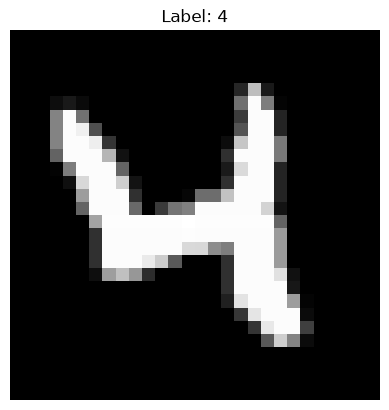

In [11]:
index_image = 20
image,label = train_dataset[index_image]
image = image.squeeze(0)
plt.imshow(image,cmap='gray')
plt.title(f"Label: {label}")
plt.axis('off')
plt.show()

We can not set the batchsize in fitting process like TF then we set it on data before fit. For this work we are going to do the below work.

Shuffle=True on train dataset >>> for dont random data select.

In [12]:
train_loader = torch.utils.data.DataLoader(train_dataset,batch_size=64,shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset,batch_size=64,shuffle=False)

Importing the Neural Network from torch for model.

In [13]:
from torch import nn

In channel = 1 >>> we have 1 channel >>> images are gray.

Out channel = 16 >>> kernel size >>> 16 with padding=same.

In [14]:
model = nn.Sequential(
    nn.Conv2d(in_channels=1,out_channels=16,kernel_size=3,padding='same'),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2,stride=2),

    nn.Conv2d(in_channels=16,out_channels=32,kernel_size=3,padding='same'),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2,stride=2),

    nn.Flatten(),
    #F.C Dense
    nn.Linear(in_features=7*7*32,out_features=128),
    nn.ReLU(),
    
    nn.Linear(in_features=128,out_features=10),
)

In [15]:
model

Sequential(
  (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=1568, out_features=128, bias=True)
  (8): ReLU()
  (9): Linear(in_features=128, out_features=10, bias=True)
)

In [16]:
# pip install torchsummary
#from torchsummary import summary

In [17]:
from torchinfo import summary

In [24]:
summary(model, input_size=(1,1,28,28))

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [1, 10]                   --
├─Conv2d: 1-1                            [1, 16, 28, 28]           160
├─ReLU: 1-2                              [1, 16, 28, 28]           --
├─MaxPool2d: 1-3                         [1, 16, 14, 14]           --
├─Conv2d: 1-4                            [1, 32, 14, 14]           4,640
├─ReLU: 1-5                              [1, 32, 14, 14]           --
├─MaxPool2d: 1-6                         [1, 32, 7, 7]             --
├─Flatten: 1-7                           [1, 1568]                 --
├─Linear: 1-8                            [1, 128]                  200,832
├─ReLU: 1-9                              [1, 128]                  --
├─Linear: 1-10                           [1, 10]                   1,290
Total params: 206,922
Trainable params: 206,922
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 1.24
Input size (MB): 0.00
Forward/b

In [28]:
# torchmetics
from torchmetrics.classification import Accuracy

In [29]:
criterion = torch.nn.CrossEntropyLoss()
opt = torch.optim.Adam(model.parameters(),lr=0.001)

In [30]:
metric = Accuracy(task='multiclass',num_classes=10)

In [32]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

metric = metric.to(device)



epochs = 5

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    
    metric.reset()
    
    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        opt.zero_grad()
        
        outputs = model(images)
        loss = criterion(outputs,labels)

        loss.backward()
        opt.step()

        # loss calculator
        running_loss += loss.item()
        
        # Accuracy calculator
        # preds = torch.argmax(outputs,dim=1)
        preds = nn.Softmax(dim=1)(outputs)
        metric.update(preds,labels)

    accuracy = metric.compute() * 100
    print(f"Epoch {epoch + 1}, Loss: {running_loss / len(train_loader):.4f}, Accuracy: {accuracy:.2f}%")

Epoch 1, Loss: 0.2351, Accuracy: 92.85%
Epoch 2, Loss: 0.0617, Accuracy: 98.06%
Epoch 3, Loss: 0.0428, Accuracy: 98.69%
Epoch 4, Loss: 0.0330, Accuracy: 98.95%
Epoch 5, Loss: 0.0265, Accuracy: 99.15%


Model evaluation

In [34]:
model.eval()
test_loss = 0.0
metric.reset()

for images, labels in test_loader:

    images = images.to(device)
    labels = labels.to(device)

    outputs = model(images)
    loss = criterion(outputs,labels)

    test_loss += loss.item()
    preds = nn.Softmax(dim=1)(outputs)
    metric.update(preds,labels)
    
accuracy = metric.compute() * 100
print(f"Test Loss: {test_loss / len(test_loader):.4f}, Accuracy: {accuracy:.2f}%")

Test Loss: 0.0370, Accuracy: 98.85%


In [41]:
torch.save(model,'model.pth') # .pt .pth

In [47]:
torch.load('model.pth' , weights_only=False)

Sequential(
  (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=1568, out_features=128, bias=True)
  (8): ReLU()
  (9): Linear(in_features=128, out_features=10, bias=True)
)

In [48]:
#######################################

Class method for Complex models.

In [49]:
class ModelCNN(nn.Module):
    def __init__(self):
        super(ModelCNN,self).__init__()

        self.conv1 = nn.Conv2d(in_channels=1,out_channels=16,kernel_size=3,padding='same')
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2,stride=2)
    
        self.conv2 = nn.Conv2d(in_channels=16,out_channels=32,kernel_size=3,padding='same')
        self.relu2 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2,stride=2)
    
        self.flatten = nn.Flatten(),
    
        self.fc1 = nn.Linear(in_features=7*7*32,out_features=128)
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(in_features=128,out_features=10)
    
    def forward(self,x):
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = self.relu2(x)
        x = self.pool2(x)

        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu3(x)
        x = self.fc2(x)
        return x

In [50]:
model = ModelCNN()

In [51]:
model

ModelCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (relu2): ReLU()
  (fc1): Linear(in_features=1568, out_features=128, bias=True)
  (relu3): ReLU()
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)